<h2> Nauczanie maszynowe/Ćwiczenia4

Jadwiga Krząstek 04.11.25

Zagadnienia na dziś:
- Sieci neuronowe - jako kombinacje przekształceń liniowych i funkcji aktywacji
- Regularyzacja w sieciach neuronowych
- Podstawy konwolucyjnych sieci neuronowych

<h4> Zadanie1: CIFAR10 to dataset zawierający 60 tysięcy kolorowych obrazków rozmiaru 32 x 32 pikseli należących do 10 różnych klas. Poniżej przykładowe wizualizacje.

<h4> Zadaniem jest zaimplementowanie "od zera" sieci konwolucyjnej do klasyfikacji wieloklasowej na zbiorze CIFAR10. Należy zaimplementować zarówno model jak i pętle uczenia oraz ewaluacji. Twój kod powinien raportować loss w trakcie trenowania, testowania oraz accuracy na zbiorze testowym (opcjonalnie również na treningowym). Na koniec accuracy powinno osiągnąć wynik powyżej 75% na zbiorze testowym. Można korzystać z dowolnych mechanizmów dostępnych w PyTorchu.

Porady do zadania:

- Zwiększenie treningowego batch size może przyspieszyć uczenie, ale należy pamiętać, że, tak jak każdy hiperparametr, batch_size ma wpływ na proces uczenia.
    
- Przy dobieraniu architektury bądź hiperparametrów nie testować dłużej niż kilka epok (około 5), tak aby mieć szybki feedback. Dopiero po dobraniu tych odpowiednich puścić dłuższe uczenie. Warto przy okazji wizualizować krzywe uczenia (funkcji kosztu) aby zwrócić uwagę na to kiedy koszt zaczyna się "wypłaszczać" i czy model przypadkowo nie overfituje (patrząc na wartości kosztu na zbiorze testowym)

In [1]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor, Normalize, Compose

C:\Users\jadwi\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\utils\generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Test pierwszego modelu, takiego samego jak zaproponowanego wyżej na zajęciach

In [2]:
from torchvision.datasets import CIFAR10
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #uzyj karty graficznej (GPU) do obliczen

#Parametry do trenowania
num_epochs = 5
num_classes = 10
batch_size = 100
learning_rate = 0.001


dataset = CIFAR10(root='.', train=True, transform=ToTensor(), download=False)
loader = DataLoader(dataset, batch_size=15, shuffle=True)

train_dataset, temp_dataset = train_test_split(dataset, test_size=0.4, random_state=42) #60
val_dataset, test_dataset = train_test_split(temp_dataset, test_size=0.5, random_state=42) #20-20

#DataLoader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size, 
                                          shuffle=False)


In [11]:
#Pierwsza siec konwolucyjna
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2), #3 warstwy rgb
            nn.BatchNorm2d(16),                                  
            nn.ReLU(),                                              
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc = nn.Linear(8*8*32, num_classes) #32 -> 16 -> 8
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

#budujemy model
model = ConvNet(num_classes).to(device)

#Wybieramy funckje kosztu i optymalizator
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#Trenujemy model na danych
total_step = len(train_loader)

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        #Krok Forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        #Krok Backward i optymalizacja
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        #co 100 przejscie wyswietl obecna wartosc funkcji kosztu
        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))

#Testujemy model
model.eval()

with torch.no_grad():
    correct = 0 #liczba poprawnie sklasyfikowanych
    total = 0  #liczba wszystkich
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Test Accuracy of the model on the 10000 test images: {100 * correct / total}')

Epoch [1/5], Step [100/300], Loss: 1.5525
Epoch [1/5], Step [200/300], Loss: 1.4793
Epoch [1/5], Step [300/300], Loss: 1.2382
Epoch [2/5], Step [100/300], Loss: 1.1615
Epoch [2/5], Step [200/300], Loss: 1.2218
Epoch [2/5], Step [300/300], Loss: 1.1875
Epoch [3/5], Step [100/300], Loss: 0.9901
Epoch [3/5], Step [200/300], Loss: 1.0238
Epoch [3/5], Step [300/300], Loss: 1.0977
Epoch [4/5], Step [100/300], Loss: 0.8007
Epoch [4/5], Step [200/300], Loss: 1.1132
Epoch [4/5], Step [300/300], Loss: 0.8006
Epoch [5/5], Step [100/300], Loss: 1.0335
Epoch [5/5], Step [200/300], Loss: 0.9423
Epoch [5/5], Step [300/300], Loss: 0.7468
Test Accuracy of the model on the 10000 test images: 59.94


Accuracy nie wyszło złe, jednak można coś zrobić, żeby je polepszyć. Dodajmy Dropout, BatchNorm i 4 konwolucje zamiast 2.

Epoch [1/15], Step [100/300], Loss: 1.5411
Epoch [1/15], Step [200/300], Loss: 1.5313
Epoch [1/15], Step [300/300], Loss: 1.1848
Epoch [2/15], Step [100/300], Loss: 1.2154
Epoch [2/15], Step [200/300], Loss: 1.0871
Epoch [2/15], Step [300/300], Loss: 1.0287
Epoch [3/15], Step [100/300], Loss: 1.3470
Epoch [3/15], Step [200/300], Loss: 1.0703
Epoch [3/15], Step [300/300], Loss: 0.9830
Epoch [4/15], Step [100/300], Loss: 0.9345
Epoch [4/15], Step [200/300], Loss: 0.9855
Epoch [4/15], Step [300/300], Loss: 1.2088
Epoch [5/15], Step [100/300], Loss: 1.0418
Epoch [5/15], Step [200/300], Loss: 0.9832
Epoch [5/15], Step [300/300], Loss: 1.0183
Epoch [6/15], Step [100/300], Loss: 0.7954
Epoch [6/15], Step [200/300], Loss: 0.8405
Epoch [6/15], Step [300/300], Loss: 0.7399
Epoch [7/15], Step [100/300], Loss: 0.8160
Epoch [7/15], Step [200/300], Loss: 0.6388
Epoch [7/15], Step [300/300], Loss: 0.6479
Epoch [8/15], Step [100/300], Loss: 0.6961
Epoch [8/15], Step [200/300], Loss: 0.5403
Epoch [8/15

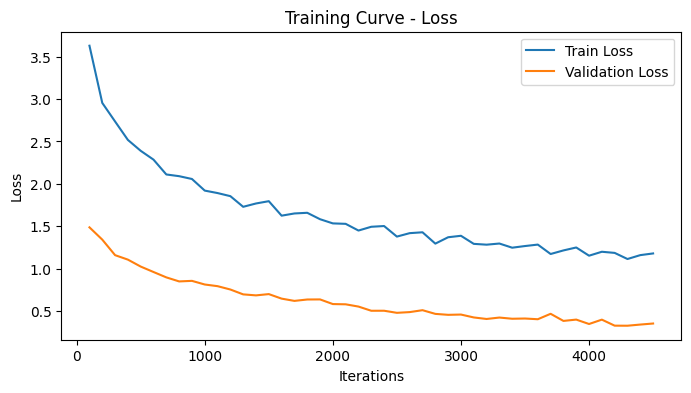

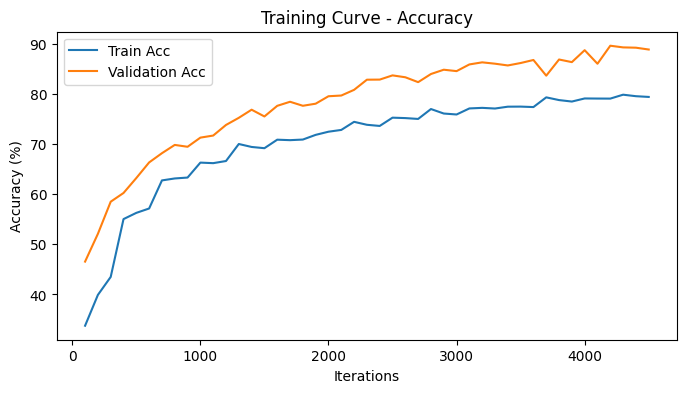

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
num_epochs = 15
val_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size, 
                                           shuffle=False)

class ConvNet2(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet2, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )
        self.fc1 = nn.Linear(8*8*64, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ConvNet2(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []
train_acc, val_acc = [], []
iters = []

iteration = 0
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0
    
    for i, (images, labels) in enumerate(train_loader):
        iteration += 1
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (i+1) % 100 == 0:
            model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for val_images, val_labels in val_loader:
                    val_images, val_labels = val_images.to(device), val_labels.to(device)
                    val_outputs = model(val_images)
                    val_loss += criterion(val_outputs, val_labels).item()
                    _, val_pred = torch.max(val_outputs.data, 1)
                    val_total += val_labels.size(0)
                    val_correct += (val_pred == val_labels).sum().item()

            val_losses.append(val_loss / len(val_loader))
            val_acc.append(100 * val_correct / val_total)
            train_losses.append(running_loss / 50)
            train_acc.append(100 * correct / total)
            iters.append(iteration)
            running_loss = 0
            model.train()

            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')


model.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total}%')

plt.figure(figsize=(8,4))
plt.plot(iters, train_losses, label='Train Loss')
plt.plot(iters, val_losses, label='Validation Loss')
plt.title("Training Curve - Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(iters, train_acc, label='Train Acc')
plt.plot(iters, val_acc, label='Validation Acc')
plt.title("Training Curve - Accuracy")
plt.xlabel("Iterations")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

**Komentarz**: uczenie zachodzi dość powoli i stopniowo, ale nie dochodzi do przetrenowania modelu - być może przy większej liczbie epok accuracy mogłoby jeszcze wzrosnąć.

<h4> Zadanie2: Rozważ tym razem dane PathMNIST. Podobnie jak wcześniej, zbuduj model klasyfikacji w oparciu o CNN. Dane należą do 1 z 9 kategorii (typy tkanek histopatologicznych). Oczekujemy przynajmniej 80 % na zbiorze testowym.

In [4]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from medmnist import PathMNIST
from medmnist import INFO

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #uzyj karty graficznej (GPU) do obliczen

#dataset = PathMNIST(root='.', train=True, transform=ToTensor(), download=False)
loader = DataLoader(dataset, batch_size=15, shuffle=True)

num_epochs = 2
num_classes = 9
batch_size = 100
learning_rate = 0.001

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = PathMNIST(split='train', transform=transform, download=False)
test_dataset  = PathMNIST(split='test', transform=transform, download=False)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size, 
                                          shuffle=False)


In [16]:
class PathNet(nn.Module):
    def __init__(self, num_classes=9):
        super(PathNet, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
        )
        #automatyczne dopasowanie rozmiaru fc1
        with torch.no_grad():
            canals = torch.zeros(1, 3, 28, 28)  #3 kanały, 28x28
            out = self.features(canals)
            flat_dim = out.view(1, -1).size(1)

        self.fc1 = nn.Linear(flat_dim , 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

        
model = PathNet(num_classes=9).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 2
total_step = len(train_loader)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        #labels = labels.squeeze().to(device)
        labels = labels.squeeze().long().to(device)

        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], "
                  f"Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    print(f"\nAccuracy on test set: {acc:.2f}%")


Epoch [1/2], Step [100/900], Loss: 1.2446
Epoch [1/2], Step [200/900], Loss: 0.8167
Epoch [1/2], Step [300/900], Loss: 0.7071
Epoch [1/2], Step [400/900], Loss: 0.6224
Epoch [1/2], Step [500/900], Loss: 0.5579
Epoch [1/2], Step [600/900], Loss: 0.5142
Epoch [1/2], Step [700/900], Loss: 0.5163
Epoch [1/2], Step [800/900], Loss: 0.4576
Epoch [1/2], Step [900/900], Loss: 0.4624
Epoch [2/2], Step [100/900], Loss: 0.4059
Epoch [2/2], Step [200/900], Loss: 0.3867
Epoch [2/2], Step [300/900], Loss: 0.3659
Epoch [2/2], Step [400/900], Loss: 0.3371
Epoch [2/2], Step [500/900], Loss: 0.3313
Epoch [2/2], Step [600/900], Loss: 0.3424
Epoch [2/2], Step [700/900], Loss: 0.3169
Epoch [2/2], Step [800/900], Loss: 0.3036
Epoch [2/2], Step [900/900], Loss: 0.3032

Accuracy on test set: 82.42%


**Komentarz**: Powyższy model zadziałał bardzo dobrze na tym zbiorze danych, accuracy 82.42%. Poniżej test więcej epok i narysowanie wykresów.

Liczba epok 4 daje najlepsze wyniki accuracy. Przy większej ilości występuje przeuczenie.

Epoch [1/4], Step [100/900], Loss: 0.8308
Epoch [1/4], Step [200/900], Loss: 0.6965
Epoch [1/4], Step [300/900], Loss: 0.6992
Epoch [1/4], Step [400/900], Loss: 0.4304
Epoch [1/4], Step [500/900], Loss: 0.5134
Epoch [1/4], Step [600/900], Loss: 0.4542
Epoch [1/4], Step [700/900], Loss: 0.3616
Epoch [1/4], Step [800/900], Loss: 0.5723
Epoch [1/4], Step [900/900], Loss: 0.3470
Epoch [2/4], Step [100/900], Loss: 0.3100
Epoch [2/4], Step [200/900], Loss: 0.3133
Epoch [2/4], Step [300/900], Loss: 0.4260
Epoch [2/4], Step [400/900], Loss: 0.3326
Epoch [2/4], Step [500/900], Loss: 0.5773
Epoch [2/4], Step [600/900], Loss: 0.3058
Epoch [2/4], Step [700/900], Loss: 0.4267
Epoch [2/4], Step [800/900], Loss: 0.2847
Epoch [2/4], Step [900/900], Loss: 0.3773
Epoch [3/4], Step [100/900], Loss: 0.2537
Epoch [3/4], Step [200/900], Loss: 0.4424
Epoch [3/4], Step [300/900], Loss: 0.3081
Epoch [3/4], Step [400/900], Loss: 0.3128
Epoch [3/4], Step [500/900], Loss: 0.3056
Epoch [3/4], Step [600/900], Loss:

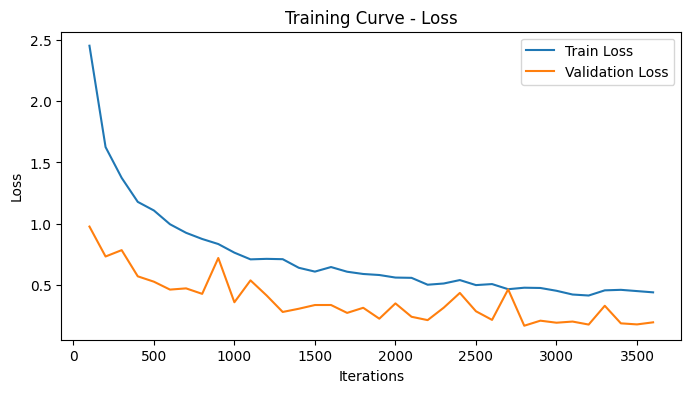

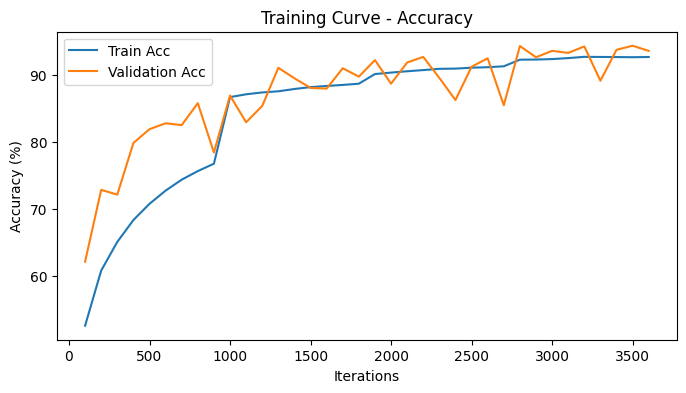

In [14]:
num_epochs = 4
model = PathNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses, train_acc, val_acc, iters = [], [], [], [], []
iteration = 0

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0

    for i, (images, labels) in enumerate(train_loader):
        iteration += 1
        images, labels = images.to(device), labels.squeeze().long().to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            model.eval()
            val_loss, val_correct, val_total = 0, 0, 0
            with torch.no_grad():
                for val_images, val_labels in val_loader:
                    val_images, val_labels = val_images.to(device), val_labels.squeeze().long().to(device)
                    val_outputs = model(val_images)
                    val_loss += criterion(val_outputs, val_labels).item()
                    _, val_pred = torch.max(val_outputs.data, 1)
                    val_total += val_labels.size(0)
                    val_correct += (val_pred == val_labels).sum().item()

            val_losses.append(val_loss / len(val_loader))
            val_acc.append(100 * val_correct / val_total)
            train_losses.append(running_loss / 50)
            train_acc.append(100 * correct / total)
            iters.append(iteration)
            running_loss = 0
            model.train()

            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    correct, total = 0, 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'\nAccuracy on test: {100 * correct / total:.2f}%')

plt.figure(figsize=(8,4))
plt.plot(iters, train_losses, label='Train Loss')
plt.plot(iters, val_losses, label='Validation Loss')
plt.title("Training Curve - Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(iters, train_acc, label='Train Acc')
plt.plot(iters, val_acc, label='Validation Acc')
plt.title("Training Curve - Accuracy")
plt.xlabel("Iterations")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

Accuracy tak jak krzywa uczenia w przypadku obu zadań dobre.